<a href="https://colab.research.google.com/github/MahuL88/Latihan/blob/main/Klasifikasi_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Biner

## Load Data

In [1]:
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
df = pd.read_csv('https://drive.google.com/uc?id=1XZbZ5Z7MBXYaR3UO1HbQ4ncPi4R3HsyF')
df.head()

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


## Preprocess

In [4]:
label_encoder = preprocessing.LabelEncoder()
df['name'] = label_encoder.fit_transform(df['name'])
print(df)

      name  diameter  weight  red  green  blue
0        1      2.96   86.76  172     85     2
1        1      3.91   88.05  166     78     3
2        1      4.42   95.17  156     81     2
3        1      4.47   95.60  163     81     4
4        1      4.48   95.76  161     72     9
...    ...       ...     ...  ...    ...   ...
9995     0     15.35  253.89  149     77    20
9996     0     15.41  254.67  148     68     7
9997     0     15.59  256.50  168     82    20
9998     0     15.92  260.14  142     72    11
9999     0     16.45  261.51  152     74     2

[10000 rows x 6 columns]


In [5]:
# mengubah dalam bentuk array(np) agar dapat diproses oleh model
dataset = df.values

In [6]:
# pilih 5 kolom terakhir sebagai atribut/fitur dan ambil semua baris
X = dataset[:,1:6]

In [7]:
# ambil semua baris pada kolom 1 sebagai label
y = dataset[:,0]

In [8]:
# split data dan buat arsitektur model
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3)

In [9]:
# Normalisasi
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X_train)
X_test_scale = min_max_scaler.transform(X_test)
X_scale

array([[0.37878788, 0.38712095, 0.42857143, 0.53246753, 0.        ],
       [0.60606061, 0.63570852, 0.38961039, 0.48051948, 0.16666667],
       [0.55741627, 0.57431108, 0.5974026 , 0.46753247, 0.        ],
       ...,
       [0.19138756, 0.19018794, 0.32467532, 0.4025974 , 0.22222222],
       [0.58293461, 0.60970829, 0.55844156, 0.27272727, 0.42592593],
       [0.60127592, 0.63046235, 0.49350649, 0.48051948, 0.53703704]])

In [10]:
model = Sequential([
                    Dense(32, activation='relu', input_shape=(5,)),
                    Dense(32, activation='relu'),
                    Dense(1, activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# menentukan optimizer(stochastic gradient descent) karena cocok utk dataset kecil dan loss function binary_crossentropy karna output biner
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train

In [12]:
# latih model
model.fit(X_train, Y_train, epochs=100)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7781 - loss: 3.4849
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8884 - loss: 0.3729
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8934 - loss: 0.2584
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8990 - loss: 0.2432
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9120 - loss: 0.2105
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9111 - loss: 0.2095
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9177 - loss: 0.2050
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9225 - loss: 0.1975
Epoch 9/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9217 - loss: 0.1930
Epoch 10/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9193 - loss: 0.1975
Epoch 11/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9188 - loss: 0.1977
Epoch 12/100
219/219 ━━━━━━━━━━━━━━━━━━

## Eval

In [13]:
# evaluasi utk melihat nilai loss dan akurasi
model.evaluate(X_test, Y_test, batch_size=1)

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9209 - loss: 0.1957


[0.19963066279888153, 0.918666660785675]

# Klasifikasi Kategorikal / Multi class

## Load Data

In [14]:
df = pd.read_csv('https://drive.google.com/uc?id=1roJ83AbgzDcvRr0Gwud0BmdUQx-oSG-w')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Preprocess

In [15]:
df = df.drop(columns='Id')

In [16]:
# Transformasi menggunakan One-Hot
category = pd.get_dummies(df.Species, dtype=int)
category

,Iris-setosa,Iris-versicolor,Iris-virginica
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
145,0,0,1
146,0,0,1
147,0,0,1
148,0,0,1


In [17]:
# gabungkan kolom hasil transform ke data utama dan hapus kolom Species dari data utama
new_df = pd.concat([df, category], axis=1)
new_df = new_df.drop(columns='Species')
new_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,0,1
146,6.3,2.5,5.0,1.9,0,0,1
147,6.5,3.0,5.2,2.0,0,0,1
148,6.2,3.4,5.4,2.3,0,0,1


In [18]:
# ubah ke bentuk array
dataset = new_df.values
dataset

array([[5.1, 3.5, 1.4, ..., 1. , 0. , 0. ],
       [4.9, 3. , 1.4, ..., 1. , 0. , 0. ],
       [4.7, 3.2, 1.3, ..., 1. , 0. , 0. ],
       ...,
       [6.5, 3. , 5.2, ..., 0. , 0. , 1. ],
       [6.2, 3.4, 5.4, ..., 0. , 0. , 1. ],
       [5.9, 3. , 5.1, ..., 0. , 0. , 1. ]])

In [19]:
# Pilih 4 kolom pertama untuk dijadikan sebagai atribut
X = dataset[:,0:4]
# Pilih 3 kolom terakhir sebagai label
y = dataset[:,4:7]

In [20]:
# split data
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3)

In [21]:
# Normalisasi
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X_train)
X_test_scale = min_max_scaler.transform(X_test)
X_scale

array([[0.44444444, 0.5       , 0.63793103, 0.70833333],
       [0.08333333, 0.45833333, 0.06896552, 0.04166667],
       [0.25      , 0.875     , 0.06896552, 0.        ],
       [0.36111111, 0.41666667, 0.51724138, 0.5       ],
       [0.58333333, 0.375     , 0.55172414, 0.5       ],
       [0.02777778, 0.5       , 0.03448276, 0.04166667],
       [0.33333333, 0.16666667, 0.44827586, 0.375     ],
       [0.86111111, 0.33333333, 0.86206897, 0.75      ],
       [0.75      , 0.5       , 0.62068966, 0.54166667],
       [0.66666667, 0.45833333, 0.77586207, 0.95833333],
       [0.16666667, 0.45833333, 0.06896552, 0.        ],
       [0.58333333, 0.5       , 0.72413793, 0.91666667],
       [0.13888889, 0.41666667, 0.05172414, 0.        ],
       [0.94444444, 0.25      , 1.        , 0.91666667],
       [0.19444444, 0.41666667, 0.0862069 , 0.04166667],
       [0.77777778, 0.41666667, 0.82758621, 0.83333333],
       [0.66666667, 0.45833333, 0.56896552, 0.54166667],
       [1.        , 0.75      ,

In [22]:
# buat arsitektur model
model = Sequential([
                    Dense(16, activation='relu', input_shape=(4,)), # cukup 16 layer saja karena fiturnya sedikit(4)
                    Dropout(0.5),
                    BatchNormalization(momentum=0.99),
                    Dense(3, activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# menentukan optimizer Adam karena cocok utk dataset kecil dan loss function categorical_crossentropy karna output kelas
model.compile(optimizer='Adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Train

In [24]:
# Membuat callback untuk memberitahu model berhenti ketika mencapai target
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.9):
      print("\nAkurasi telah mencapai >90%!")
      self.model.stop_training = True
callbacks = myCallback()  #membuat objek dari kelas

In [25]:
hist = model.fit(X_scale, Y_train, epochs=100, callbacks = [callbacks])

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4790 - loss: 1.1418
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3881 - loss: 1.2257
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5199 - loss: 1.0662
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4325 - loss: 1.0612
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5356 - loss: 0.9056
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4981 - loss: 0.9939
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5428 - loss: 0.8922
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5453 - loss: 0.8533
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4558 - loss: 0.9733 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5359 - loss: 0.9126
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5959 - loss: 0.8534
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5085 - los

## Plot Akurasi dan Loss

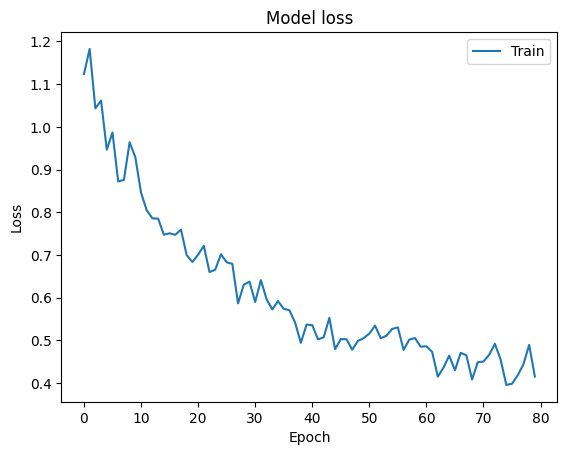

In [26]:
# Loss
plt.plot(hist.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')
plt.show()

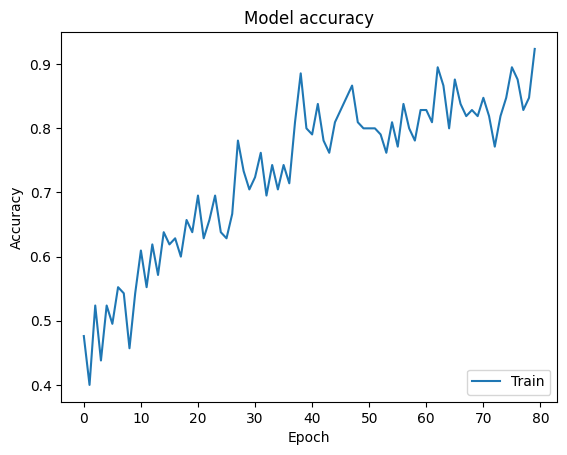

In [27]:
# Akurasi
plt.plot(hist.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='lower right')
plt.show()

## Eval

In [28]:
model.evaluate(X_test_scale, Y_test, batch_size=1)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8951 - loss: 0.4913


[0.5245009660720825, 0.9111111164093018]